In [13]:
import json
with open('bbox_results_processed.json', 'r') as file:
    data_all = json.load(file)



In [22]:
data = data_all[75]
data


{'open_image_input_url': 'https://farm3.staticflickr.com/555/19084129158_a34b41fee3_o.jpg',
 'text': "Integrate a small, dark-toned vintage bicycle with a wicker basket leaning against the facade of the building on the left side of the street, near the outdoor cafe, ensuring its monochrome appearance, lighting, and shadow blend seamlessly with the existing scene's texture and atmosphere.",
 'output_image': 'openimages/edited/sft/249.png',
 'edit_type': 'Add a new object to the scene',
 'summarized_text': 'Add a small, dark vintage bicycle with a wicker basket against the building, blending with the scene.',
 'local_input_image': 'openimages/source/train_0/000578c4cbd9c9f2.jpg',
 'bbox': {'objects': [{'is_remove': False,
    'bbox': [35, 805, 375, 972],
    'region_point': [185, 880],
    'description': 'new vintage bicycle with wicker basket leaning against the building on the left',
    'extracted_word': ['bicycle']},
   {'is_remove': True,
    'bbox': [165, 806, 225, 960],
    'regio

In [23]:
inimg = Image.open(data['local_input_image']).convert("RGB")
outimg = Image.open(data['output_image']).convert("RGB")


In [24]:
point_out = data['bbox']['objects'][1]['region_point']
point_in = data['bbox']['objects'][0]['region_point']

In [25]:
from PIL import ImageDraw

# Get image sizes
width_in, height_in = inimg.size
width_out, height_out = outimg.size

# Scale points from 0-1000 to image dimensions
point_in_scaled = (
    point_in[0] * width_in / 1000,
    point_in[1] * height_in / 1000
)
point_out_scaled = (
    point_out[0] * width_out / 1000,
    point_out[1] * height_out / 1000
)

# Draw points
draw_in = ImageDraw.Draw(inimg)
draw_in.point(point_in_scaled, fill="red")
draw_out = ImageDraw.Draw(outimg)
draw_out.point(point_out_scaled, fill="red")

(np.float64(-0.5), np.float64(831.5), np.float64(1247.5), np.float64(-0.5))

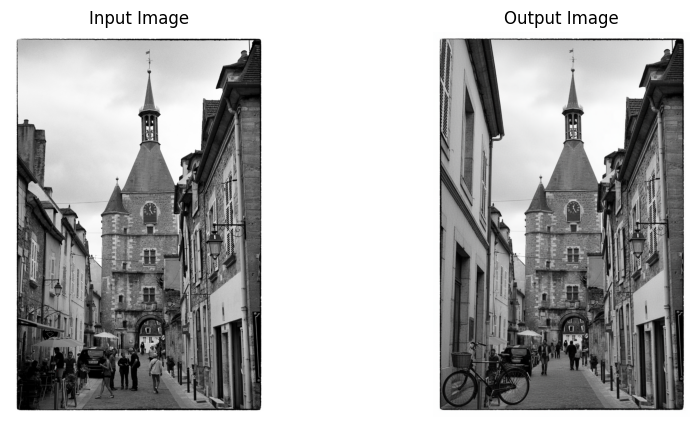

In [26]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(inimg)
axs[0].set_title('Input Image')
axs[0].axis('off')
axs[1].imshow(outimg)
axs[1].set_title('Output Image')
axs[1].axis('off')

In [1]:
import argparse
import json
import torch
import numpy as np
from diffusers import FluxKontextPipeline
pipe = FluxKontextPipeline.from_pretrained("black-forest-labs/FLUX.1-Kontext-dev", torch_dtype=torch.bfloat16).to('cuda')


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers
You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [8]:
import PIL.Image as Image
img = Image.open("openimages/top_down_output/idx_391_2674_input_to_pipe.png").convert("RGB")
obj = "rainbow"

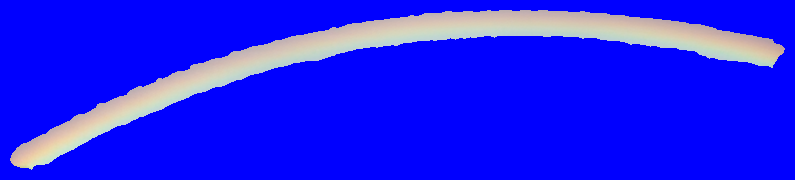

In [9]:
img

In [10]:
import random
prompt = f"Complete the {obj} and put the {obj} in a realistic and fitting environment, ensuring the background is consistent with the object. Maintain accurate lighting, proportions, and shadows. Random views."
seed = random.randint(0, 2**32 - 1)
generator = torch.Generator(device="cuda").manual_seed(seed)
generated_image = pipe(
    image=img, 
    prompt=prompt,
    guidance_scale=2.5,
    width=1024,
    height=1024,
    num_inference_steps=50,
    generator=generator, # Use the dynamically generated seed
).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

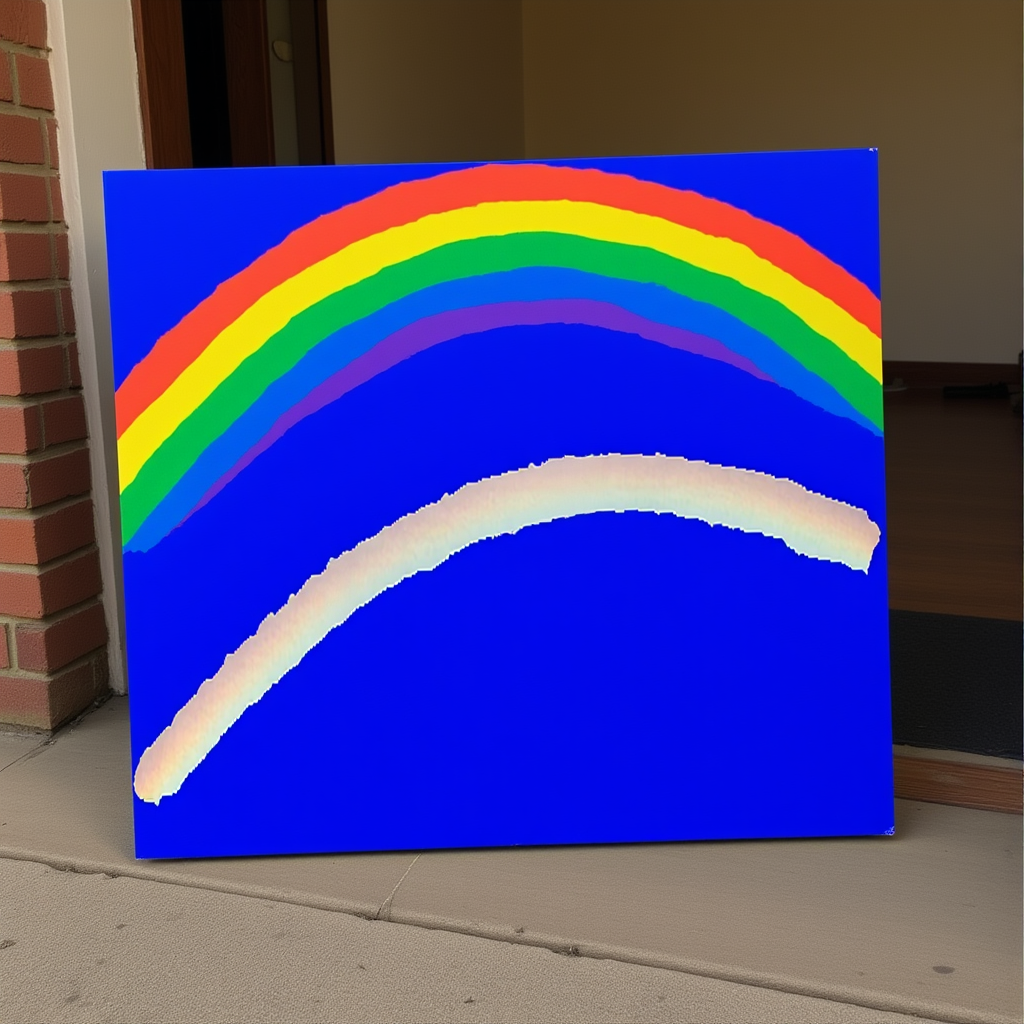

In [11]:
generated_image